<a href="https://colab.research.google.com/github/manavsharma111/Machine-Learning/blob/main/Network_Traffic_Prediction_%26_Congestion_Control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [72]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kimdaegyeom/5g-traffic-datasets")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/kimdaegyeom/5g-traffic-datasets/versions/1


In [73]:
import os

# List the contents of the downloaded directory to find the correct file path
print(os.listdir(path))

['5G_Traffic_Datasets']


In [74]:
import os

# List the contents of the '5G_Traffic_Datasets' subdirectory
print(os.listdir(os.path.join(path, '5G_Traffic_Datasets')))

['Game_Streaming', 'Stored_Streaming', 'Video_Conferencing', 'Metaverse', 'Online_Game', 'Live_Streaming']


In [75]:
import os

# Construct the path to the 'Game_Streaming' subdirectory
game_streaming_path = os.path.join(path, '5G_Traffic_Datasets', 'Game_Streaming')

# List the contents of the 'Game_Streaming' subdirectory
print(os.listdir(game_streaming_path))

['KT_GameBox', 'GeForce_Now']


In [76]:
import os

# Construct the path to the 'GeForce_Now' subdirectory
geforce_now_path = os.path.join(game_streaming_path, 'GeForce_Now')

# List the contents of the 'GeForce_Now' subdirectory
print(os.listdir(geforce_now_path))

['GeForce_Now_4.csv', 'GeForce_Now_3.csv', 'GeForce_Now_5.csv', 'GeForce_Now_9.csv', 'GeForce_Now_6.csv', 'GeForce_Now_2.csv', 'GeForce_Now_7.csv', 'GeForce_Now_8.csv', 'GeForce_Now_1.csv']


In [77]:
import pandas as pd
import os
import kagglehub

# Re-define path variables to ensure they are in scope
path = kagglehub.dataset_download("kimdaegyeom/5g-traffic-datasets")
game_streaming_path = os.path.join(path, '5G_Traffic_Datasets', 'Game_Streaming')
geforce_now_path = os.path.join(game_streaming_path, 'GeForce_Now')

# Construct the full path to the specific CSV file
file_path = os.path.join(geforce_now_path, 'GeForce_Now_1.csv')

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
print("DataFrame loaded successfully. First 5 rows:")
print(df.head())

DataFrame loaded successfully. First 5 rows:
   No.                        Time           Source      Destination Protocol  \
0  436  2022-09-27 13:08:31.564846     10.215.173.1  112.217.128.200      TCP   
1  443  2022-09-27 13:08:31.593193  112.217.128.200     10.215.173.1      TCP   
2  444  2022-09-27 13:08:31.593329     10.215.173.1  112.217.128.200      TCP   
3  445  2022-09-27 13:08:31.594817     10.215.173.1  112.217.128.200  TLSv1.2   
4  446  2022-09-27 13:08:31.594972  112.217.128.200     10.215.173.1      TCP   

   Length                                               Info  
0      60  58632  >  443 [SYN] Seq=0 Win=65535 Len=0 MSS=...  
1      48  443  >  58632 [SYN, ACK] Seq=0 Ack=1 Win=2048 ...  
2      40    58632  >  443 [ACK] Seq=1 Ack=1 Win=79872 Len=0  
3     557                                       Client Hello  
4      40  443  >  58632 [ACK] Seq=1 Ack=518 Win=2096128 ...  


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957337 entries, 0 to 3957336
Data columns (total 7 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   No.          int64 
 1   Time         object
 2   Source       object
 3   Destination  object
 4   Protocol     object
 5   Length       int64 
 6   Info         object
dtypes: int64(2), object(5)
memory usage: 211.3+ MB


In [79]:
df.isnull().sum()

,0
No.,0
Time,0
Source,0
Destination,0
Protocol,0
Length,0
Info,1


In [80]:
# Time column to datetime objects
df['Time'] = pd.to_datetime(df['Time'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957337 entries, 0 to 3957336
Data columns (total 7 columns):
 #   Column       Dtype         
---  ------       -----         
 0   No.          int64         
 1   Time         datetime64[ns]
 2   Source       object        
 3   Destination  object        
 4   Protocol     object        
 5   Length       int64         
 6   Info         object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 211.3+ MB


In [81]:
print("\nDescriptive statistics for numerical columns:")
print(df.describe())


Descriptive statistics for numerical columns:
                No.                           Time        Length
count  3.957337e+06                        3957337  3.957337e+06
mean   2.057829e+06  2022-09-27 13:47:10.157307392  8.261105e+02
min    4.360000e+02     2022-09-27 13:08:31.564846  3.600000e+01
25%    1.068323e+06  2022-09-27 13:34:26.201093888  3.290000e+02
50%    2.057961e+06  2022-09-27 13:46:59.870351104  1.332000e+03
75%    3.047295e+06  2022-09-27 14:00:45.900176896  1.332000e+03
max    4.036716e+06     2022-09-27 14:14:51.073921  1.000000e+04
std    1.142578e+06                            NaN  5.350107e+02


In [82]:
df['Protocol'].unique()

array(['TCP', 'TLSv1.2', 'UDP', 'RTCP', 'Pathport'], dtype=object)

In [83]:
print(df['Protocol'].value_counts())
print(df['Info'].value_counts())
print(df['Destination'].value_counts())
print(df['Source'].value_counts())
print(df['Time'].value_counts())

Protocol
UDP         3953607
TCP            1811
TLSv1.2        1811
RTCP            107
Pathport          1
Name: count, dtype: int64
Info
19148  >  49005 Len=1304                                      2014731
13064  >  49003 Len=301                                        702625
49004  >  19779 Len=109                                        351317
13064  >  49003 Len=313                                        351312
18747  >  49006 Len=10                                         119439
                                                               ...   
322  >  42698 [ACK] Seq=106236 Ack=28032 Win=2096128 Len=0          1
322  >  42698 [ACK] Seq=106236 Ack=27992 Win=2096128 Len=0          1
322  >  42698 [ACK] Seq=106236 Ack=27952 Win=2096128 Len=0          1
322  >  42698 [ACK] Seq=106236 Ack=27912 Win=2096128 Len=0          1
322  >  42698 [ACK] Seq=106236 Ack=28512 Win=2096128 Len=0          1
Name: count, Length: 3526, dtype: int64
Destination
10.215.173.1       3430593
112.217.128

In [84]:
# Map 'Source' column to numerical values using factorize
df['Source'], unique_source_labels = pd.factorize(df['Source'])

print("\nUpdated 'Source' column after mapping:")
print(df['Source'].value_counts())


Updated 'Source' column after mapping:
Source
1    3430593
0     526744
Name: count, dtype: int64


In [85]:
# Map 'Destination' column to numerical values using factorize
df['Destination'], unique_destination_labels = pd.factorize(df['Destination'])

print("\nUpdated 'Destination' column after mapping:")
print(df['Destination'].value_counts())


Updated 'Destination' column after mapping:
Destination
1    3430593
0     526744
Name: count, dtype: int64


In [86]:
# Map 'Info' column to numerical values using factorize
df['Info'], unique_info_labels = pd.factorize(df['Info'])

print("\nUpdated 'Info' column (first 10 unique factorized values):")
print(df['Info'].value_counts().head(10))


Updated 'Info' column (first 10 unique factorized values):
Info
79     2014731
71      702625
98      351317
72      351312
77      119439
105      71692
119      28275
192      24607
114      13270
148      12846
Name: count, dtype: int64


In [88]:
df['Protocol'], unique_protocol_labels = pd.factorize(df['Protocol'])

print("\nUpdated 'Protocol' column after mapping:")
print(df['Protocol'].value_counts())


Updated 'Protocol' column after mapping:
Protocol
2    3953607
0       1811
1       1811
3        107
4          1
Name: count, dtype: int64


In [92]:
df['Time'],unique_time_labels = pd.factorize(df['Time'])

print("\nUpdated 'Time' column after mapping:")
print(df['Time'].value_counts())


Updated 'Time' column after mapping:
Time
3957336    1
0          1
1          1
2          1
3          1
          ..
13         1
12         1
11         1
10         1
9          1
Name: count, Length: 3957337, dtype: int64


In [93]:
# Display the DataFrame info and head to verify all relevant columns are now numerical
print("\nDataFrame info after all categorical mappings:")
df.info()

print("\nDataFrame head after all categorical mappings:")
print(df.head())


DataFrame info after all categorical mappings:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957337 entries, 0 to 3957336
Data columns (total 7 columns):
 #   Column       Dtype
---  ------       -----
 0   No.          int64
 1   Time         int64
 2   Source       int64
 3   Destination  int64
 4   Protocol     int64
 5   Length       int64
 6   Info         int64
dtypes: int64(7)
memory usage: 211.3 MB

DataFrame head after all categorical mappings:
   No.  Time  Source  Destination  Protocol  Length  Info
0  436     0       0            0         0      60     0
1  443     1       1            1         0      48     1
2  444     2       0            0         0      40     2
3  445     3       0            0         1     557     3
4  446     4       1            1         0      40     4


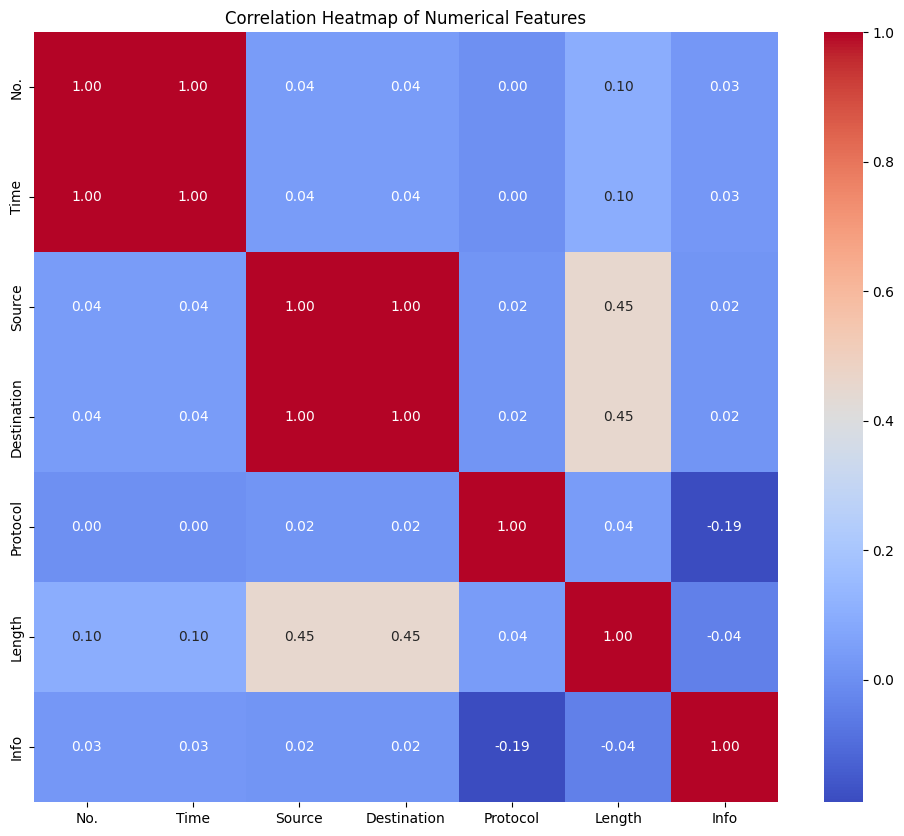

In [94]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [95]:
# Restore 'Time' column to datetime objects using the original unique labels
df['Time'] = pd.Series(unique_time_labels[df['Time']].values)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957337 entries, 0 to 3957336
Data columns (total 7 columns):
 #   Column       Dtype         
---  ------       -----         
 0   No.          int64         
 1   Time         datetime64[ns]
 2   Source       int64         
 3   Destination  int64         
 4   Protocol     int64         
 5   Length       int64         
 6   Info         int64         
dtypes: datetime64[ns](1), int64(6)
memory usage: 211.3 MB


In [96]:
# Extract time-based features
df['hour'] = df['Time'].dt.hour
df['day_of_week'] = df['Time'].dt.dayofweek # Monday=0, Sunday=6
df['day_of_month'] = df['Time'].dt.day
df['month'] = df['Time'].dt.month
df['day_of_year'] = df['Time'].dt.dayofyear

print("DataFrame with new time-based features:")

DataFrame with new time-based features:


In [97]:
display(df.head())

,No.,Time,Source,Destination,Protocol,Length,Info,hour,day_of_week,day_of_month,month,day_of_year
0,436,2022-09-27 13:08:31.564846,0,0,0,60,0,13,1,27,9,270
1,443,2022-09-27 13:08:31.593193,1,1,0,48,1,13,1,27,9,270
2,444,2022-09-27 13:08:31.593329,0,0,0,40,2,13,1,27,9,270
3,445,2022-09-27 13:08:31.594817,0,0,1,557,3,13,1,27,9,270
4,446,2022-09-27 13:08:31.594972,1,1,0,40,4,13,1,27,9,270


In [106]:
# Define features (X) and target (Y)
X = df[['hour', 'day_of_week', 'day_of_month', 'month', 'day_of_year', 'Source', 'Destination', 'Protocol', 'Info']]
Y = df['Length']

print("Features (X) head:")
display(X.head())

print("\nTarget (Y) head:")
display(Y.head())

Features (X) head:


,hour,day_of_week,day_of_month,month,day_of_year,Source,Destination,Protocol,Info
0,13,1,27,9,270,0,0,0,0
1,13,1,27,9,270,1,1,0,1
2,13,1,27,9,270,0,0,0,2
3,13,1,27,9,270,0,0,1,3
4,13,1,27,9,270,1,1,0,4



Target (Y) head:


,Length
0,60
1,48
2,40
3,557
4,40


In [108]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (3165869, 9)
X_test shape: (791468, 9)
Y_train shape: (3165869,)
Y_test shape: (791468,)


In [109]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, accuracy_score
import time

In [110]:
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
start_time = time.time()
# Training of model
rf_model.fit(X_train, Y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"Model training completed in {training_time:.2f} seconds.")

Model training completed in 62.42 seconds.


In [113]:
# Prediction
Y_pred = rf_model.predict(X_test)
# Evaluate the model
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, Y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Model Evaluation:
Mean Absolute Error (MAE): 0.05
Mean Squared Error (MSE): 151.52
Root Mean Squared Error (RMSE): 12.31
R-squared (R2): 1.00


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

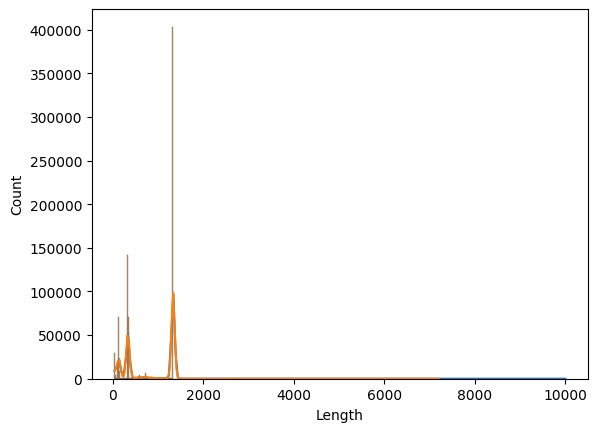

In [119]:
sns.histplot(Y_test, label='Actual', kde=True)
sns.histplot(Y_pred, label='Predicted', kde=True)
plt

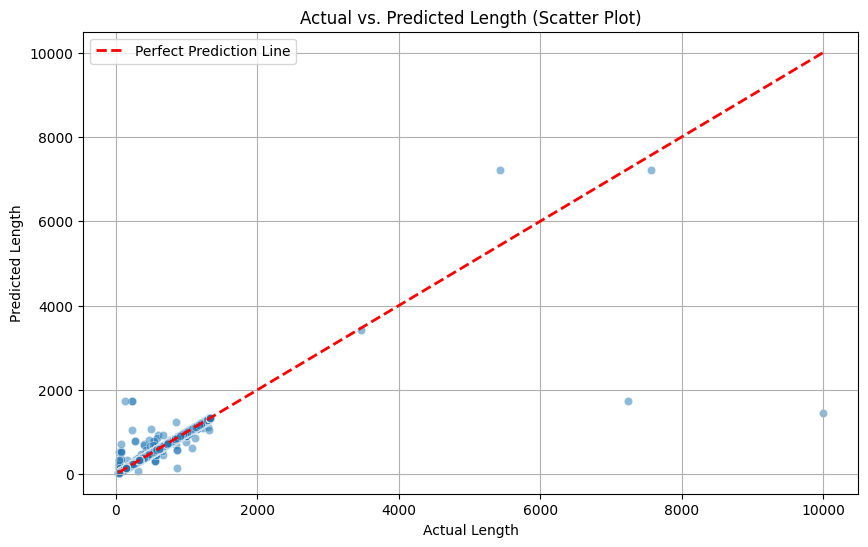

In [120]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=Y_test, y=Y_pred, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Length')
plt.ylabel('Predicted Length')
plt.title('Actual vs. Predicted Length (Scatter Plot)')
plt.legend()
plt.grid(True)
plt.show()